In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\Roman Shypka\lab3.csv")

In [16]:
df.columns = df.columns.str.strip()

In [17]:
df

,Month,Temp
0,1,-2
1,2,0
2,3,5
3,4,10
4,5,15
5,6,20
6,7,23
7,8,22
8,9,17
9,10,10


In [18]:
x = df['Month']
y = df['Temp']

In [22]:
def form_matrix(x, m):
    """Формування матриці системи """
    A = [[0.0] * (m + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        for j in range(m + 1):
            A[i][j] = sum((xi ** (i + j)) for xi in x)
    return A

def form_vector(x, y, m):
    """Формування вектора вільних членів """
    b = [0.0] * (m + 1)
    for i in range(m + 1):
        b[i] = sum(yi * (xi ** i) for xi, yi in zip(x, y))
    return b

def gauss_solve(A, b):
    """Метод Гауса з вибором головного елемента """
    n = len(A)
    A = [row[:] for row in A]
    b = b[:]

    for k in range(n - 1):
        max_row = k
        for i in range(k + 1, n):
            if abs(A[i][k]) > abs(A[max_row][k]):
                max_row = i
        A[k], A[max_row] = A[max_row], A[k]
        b[k], b[max_row] = b[max_row], b[k]

        for i in range(k + 1, n):
            if A[k][k] == 0: continue
            factor = A[i][k] / A[k][k]
            for j in range(k, n):
                A[i][j] -= factor * A[k][j]
            b[i] -= factor * b[k]

    x_sol = [0.0] * n
    for i in range(n - 1, -1, -1):
        if A[i][i] == 0: return [0.0] * n 
        s = sum(A[i][j] * x_sol[j] for j in range(i + 1, n))
        x_sol[i] = (b[i] - s) / A[i][i]
    return x_sol

def polynomial(x_val, coef):
    """Обчислення полінома """
    return sum(c * (x_val ** i) for i, c in enumerate(coef))

def variance(y_true, y_approx):
    """Обчислення дисперсії з використанням numpy """
    n = len(y_true) - 1
    # Перетворюємо списки в numpy-масиви для швидкого поелементного віднімання та піднесення до квадрату
    yt_arr = np.array(y_true)
    ya_arr = np.array(y_approx)
    
    s_sq = np.sum((yt_arr - ya_arr) ** 2)
    return np.sqrt(s_sq / (n + 1))

In [23]:
max_degree = 10 
variances = []
best_m = 1
min_var = float('inf')
best_coef = []

print("--- Пошук оптимального степеня (m від 1 до 10) ---")
for m in range(1, max_degree + 1):
    A = form_matrix(x, m)
    b_vec = form_vector(x, y, m)
    coef = gauss_solve(A, b_vec)
    
    y_approx = [polynomial(xi, coef) for xi in x]
    var = variance(y, y_approx)
    variances.append(var)
    
    print(f"Степінь m={m}: Дисперсія = {var:.4f}")
    
    if var < min_var:
        min_var = var
        best_m = m
        best_coef = coef

print(f"\n=> Оптимальний степінь: m = {best_m} (дисперсія: {min_var:.4f})")

--- Пошук оптимального степеня (m від 1 до 10) ---
Степінь m=1: Дисперсія = 8.6904
Степінь m=2: Дисперсія = 8.6027
Степінь m=3: Дисперсія = 8.5309
Степінь m=4: Дисперсія = 5.4080
Степінь m=5: Дисперсія = 5.1160
Степінь m=6: Дисперсія = 2.8140
Степінь m=7: Дисперсія = 2.8122
Степінь m=8: Дисперсія = 1.9145
Степінь m=9: Дисперсія = 1.9136
Степінь m=10: Дисперсія = 1.6862

=> Оптимальний степінь: m = 10 (дисперсія: 1.6862)


In [25]:
# Обчислення значень та похибок для найкращого полінома
y_approx_best = [polynomial(xi, best_coef) for xi in x]
errors = [abs(yt - ya) for yt, ya in zip(y, y_approx_best)]

# Прогноз на наступні 3 місяці
last_month = int(max(x))
x_future = [last_month + 1, last_month + 2, last_month + 3]
y_future = [polynomial(xi, best_coef) for xi in x_future]

print("--- Прогноз на наступні 3 місяці ---")
for mth, temp in zip(x_future, y_future):
    print(f"Місяць {mth}: {temp:.2f} °C")

--- Прогноз на наступні 3 місяці ---
Місяць 25: 16.06 °C
Місяць 26: 120.99 °C
Місяць 27: 503.27 °C


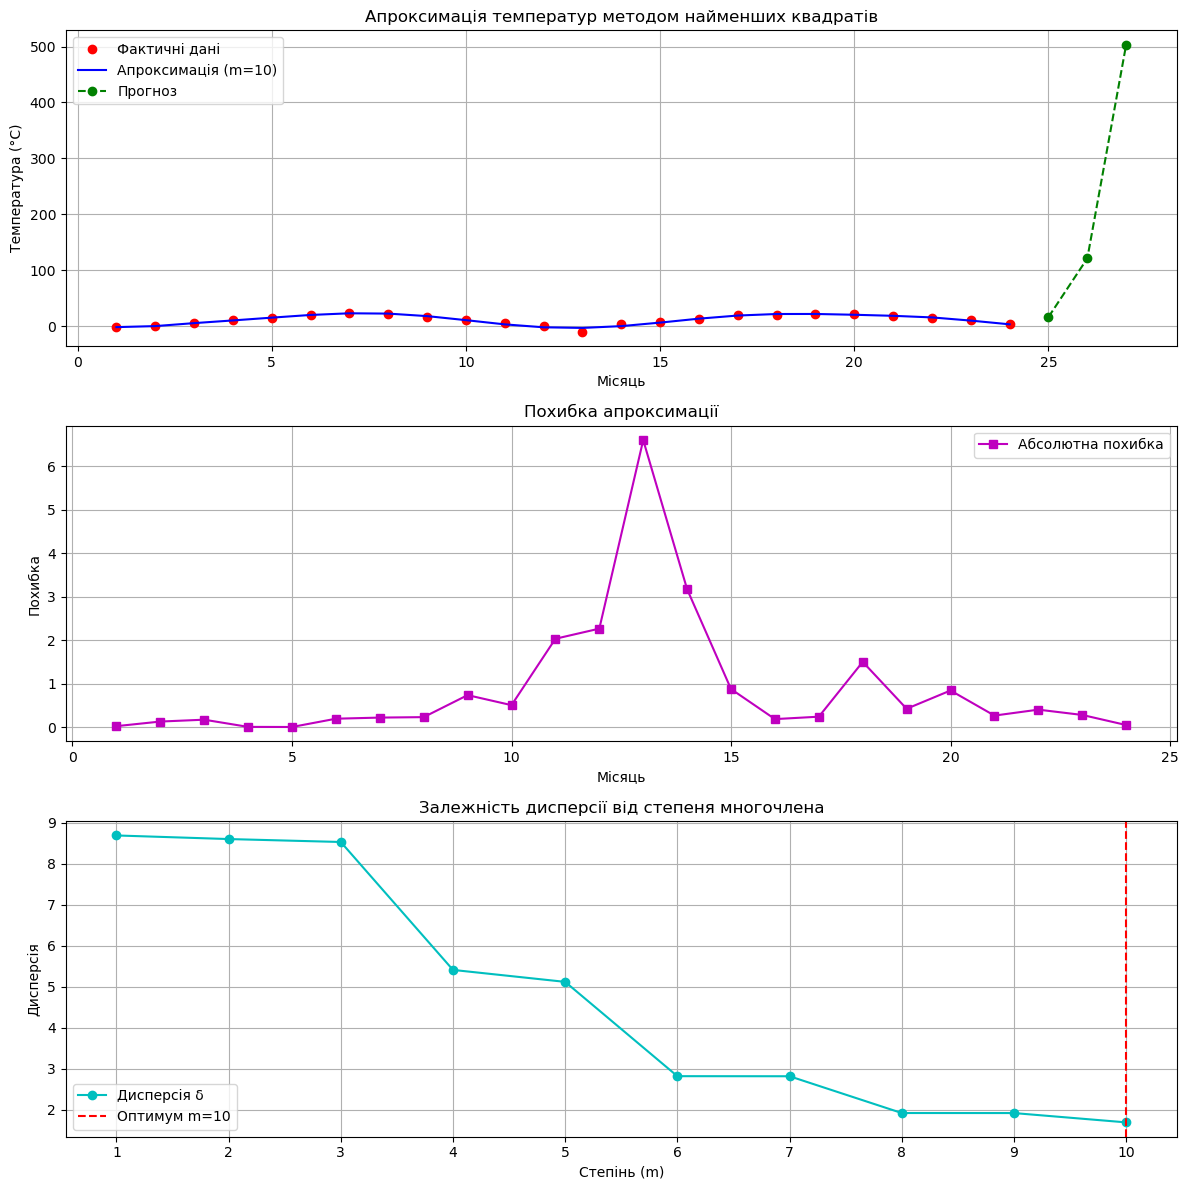

In [26]:
plt.figure(figsize=(12, 12))

# Графік 1: Апроксимація та прогноз
plt.subplot(3, 1, 1)
plt.plot(x, y, 'ro', label='Фактичні дані')
plt.plot(x, y_approx_best, 'b-', label=f'Апроксимація (m={best_m})')
plt.plot(x_future, y_future, 'go--', label='Прогноз')
plt.title('Апроксимація температур методом найменших квадратів')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True)

# Графік 2: Похибка
plt.subplot(3, 1, 2)
plt.plot(x, errors, 'm-s', label='Абсолютна похибка')
plt.title('Похибка апроксимації')
plt.xlabel('Місяць')
plt.ylabel('Похибка')
plt.legend()
plt.grid(True)

# Графік 3: Дисперсія
plt.subplot(3, 1, 3)
m_values = list(range(1, max_degree + 1))
plt.plot(m_values, variances, 'c-o', label='Дисперсія δ')
plt.axvline(x=best_m, color='r', linestyle='--', label=f'Оптимум m={best_m}')
plt.title('Залежність дисперсії від степеня многочлена')
plt.xlabel('Степінь (m)')
plt.ylabel('Дисперсія')
plt.xticks(m_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()